# Chemistry transformer
We will use a transformer model to predict solubility from SMILES sequence

# Install Packages
Only run if you do not have packages installed

In [ ]:
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio #note this will install pytorch for CPU


# Load data

In [21]:
import math
import random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("delaney.csv")

smiles_column = "SMILES"
target_column = "measured log(solubility:mol/L)"

# Set model params

In [22]:
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-5

MAX_LEN = 128
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
DIM_FEEDFORWARD = 256
DROPOUT = 0.1

TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Smiles tokenizer and pytorch dataset
We need to tokenize our smiles. We will do this at the character level like we did for the LSTM, again this is not ideal.

In [23]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<cls>"] # we also need a token to indicate the end of the SMILES string

def build_vocab(smiles_list):
    chars = sorted(set("".join(smiles_list)))
    tokens = SPECIAL_TOKENS + chars
    stoi = {tok: i for i, tok in enumerate(tokens)}
    itos = {i: tok for tok, i in stoi.items()}
    return stoi, itos

def encode_smiles(smiles, stoi, max_len):
    """
    Converts a SMILES string into a fixed-length integer sequence.

    We prepend a <cls> token, then pad or truncate to max_len.
    """
    tokens = ["<cls>"] + list(smiles)

    ids = []
    for tok in tokens[:max_len]:
        ids.append(stoi.get(tok, stoi["<unk>"]))

    attention_mask = [1] * len(ids)

    while len(ids) < max_len:
        ids.append(stoi["<pad>"])
        attention_mask.append(0)

    return torch.tensor(ids, dtype=torch.long), torch.tensor(attention_mask, dtype=torch.bool)

class DelaneySmilesDataset(Dataset):
    def __init__(self, dataframe, stoi, target_scaler=None, fit_scaler=False):
        self.df = dataframe.reset_index(drop=True)
        self.stoi = stoi

        y = self.df[target_column].values.astype(np.float32).reshape(-1, 1)

        if target_scaler is None:
            target_scaler = StandardScaler()

        if fit_scaler:
            y = target_scaler.fit_transform(y)
        else:
            y = target_scaler.transform(y)

        self.y = y.astype(np.float32).flatten()
        self.target_scaler = target_scaler

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        smiles = self.df.loc[idx, smiles_column]
        input_ids, attention_mask = encode_smiles(smiles, self.stoi, MAX_LEN)
        target = torch.tensor(self.y[idx], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "target": target,
        }



# Code to set up transformer

In [24]:
#positional encoding allows the transformer to know where in the sequence the character is
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        #sin and cos functions are used for positional encoding
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x shape: [batch_size, seq_len, d_model]
        """
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

#transformer model
class SmilesTransformerRegressor(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_idx,
        d_model=128,
        n_heads=4,
        n_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        max_len=128,
    ):
        super().__init__()

        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model,
            padding_idx=pad_idx,
        )

        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.regression_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, input_ids, attention_mask):
        """
        input_ids shape: [batch_size, seq_len]
        attention_mask shape: [batch_size, seq_len]
            True means real token.
            False means padding token.
        """

        x = self.embedding(input_ids)
        x = self.pos_encoder(x)

        # PyTorch transformer expects True for positions that should be ignored.
        src_key_padding_mask = ~attention_mask

        x = self.transformer_encoder(
            x,
            src_key_padding_mask=src_key_padding_mask,
        )

        # Use the <cls> token representation for regression.
        cls_embedding = x[:, 0, :]

        prediction = self.regression_head(cls_embedding).squeeze(-1)

        return prediction

# Training and evaluation

In [25]:
def train_one_epoch(model, dataloader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        optimizer.zero_grad()

        pred = model(input_ids, attention_mask)
        loss = loss_fn(pred, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

    return total_loss / len(dataloader.dataset)


@torch.no_grad()
def evaluate(model, dataloader, loss_fn, target_scaler=None):
    model.eval()
    total_loss = 0.0

    all_preds = []
    all_targets = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        pred = model(input_ids, attention_mask)
        loss = loss_fn(pred, target)

        total_loss += loss.item() * input_ids.size(0)

        all_preds.append(pred.cpu().numpy())
        all_targets.append(target.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    if target_scaler is not None:
        all_preds_unscaled = target_scaler.inverse_transform(
            all_preds.reshape(-1, 1)
        ).flatten()

        all_targets_unscaled = target_scaler.inverse_transform(
            all_targets.reshape(-1, 1)
        ).flatten()
    else:
        all_preds_unscaled = all_preds
        all_targets_unscaled = all_targets

    rmse = mean_squared_error(
        all_targets_unscaled,
        all_preds_unscaled,
        squared=False,
    )

    r2 = r2_score(all_targets_unscaled, all_preds_unscaled)

    avg_loss = total_loss / len(dataloader.dataset)

    return avg_loss, rmse, r2


# get relevant columns
df = df[[smiles_column, target_column]].dropna()
df[smiles_column] = df[smiles_column].astype(str)

print(df.head())
print(f"Dataset size: {len(df)}")

stoi, itos = build_vocab(df[smiles_column].tolist())

print(f"Vocabulary size: {len(stoi)}")
print(stoi)

train_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, random_state=42)

print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

#just like with input features, scaling the target can also improve performance
target_scaler = StandardScaler()
train_dataset = DelaneySmilesDataset(
    train_df,
    stoi,
    target_scaler=target_scaler,
    fit_scaler=True,
)

val_dataset = DelaneySmilesDataset(
    val_df,
    stoi,
    target_scaler=target_scaler,
    fit_scaler=False,
)

test_dataset = DelaneySmilesDataset(
    test_df,
    stoi,
    target_scaler=target_scaler,
    fit_scaler=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

model = SmilesTransformerRegressor(
    vocab_size=len(stoi),
    pad_idx=stoi["<pad>"],
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=MAX_LEN,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

loss_fn = nn.MSELoss()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        loss_fn,
    )

    val_loss, val_rmse, val_r2 = evaluate(
        model,
        val_loader,
        loss_fn,
        target_scaler=target_scaler,
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val R2: {val_r2:.4f}"
    )

test_loss, test_rmse, test_r2 = evaluate(
    model,
    test_loader,
    loss_fn,
    target_scaler=target_scaler,
)        

print("\nTest set performance")
print(f"Test loss: {test_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2: {test_r2:.4f}")

                SMILES  measured log(solubility:mol/L)
0       ClCC(Cl)(Cl)Cl                           -2.18
1         CC(Cl)(Cl)Cl                           -2.00
2       ClC(Cl)C(Cl)Cl                           -1.74
3           ClCC(Cl)Cl                           -1.48
4  FC(F)(Cl)C(F)(Cl)Cl                           -3.04
Dataset size: 1144
Vocabulary size: 35
{'<pad>': 0, '<unk>': 1, '<cls>': 2, ' ': 3, '#': 4, '(': 5, ')': 6, '/': 7, '1': 8, '2': 9, '3': 10, '4': 11, '5': 12, '6': 13, '7': 14, '8': 15, '=': 16, 'B': 17, 'C': 18, 'F': 19, 'H': 20, 'I': 21, 'N': 22, 'O': 23, 'P': 24, 'S': 25, '[': 26, '\\': 27, ']': 28, 'c': 29, 'l': 30, 'n': 31, 'o': 32, 'r': 33, 's': 34}
Train: 826
Val:   146
Test:  172


C:\Users\allis\AppData\Local\Temp\ipykernel_12320\1757611520.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(
C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Epoch 001 | Train loss: 0.9131 | Val loss: 0.7033 | Val RMSE: 1.7652 | Val R2: 0.2498


C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Epoch 002 | Train loss: 0.6685 | Val loss: 0.5235 | Val RMSE: 1.5229 | Val R2: 0.4416


...

C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Epoch 019 | Train loss: 0.1528 | Val loss: 0.1646 | Val RMSE: 0.8540 | Val R2: 0.8244


C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Epoch 020 | Train loss: 0.1508 | Val loss: 0.1583 | Val RMSE: 0.8375 | Val R2: 0.8311

Test set performance
Test loss: 0.1644
Test RMSE: 0.8534
Test R2: 0.8347


C:\Users\allis\anaconda3\envs\AI_class\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Graph results
We will graph the true vs predicted values. Since we scaled the values we will have to reverse the scale first

NameError: name 'all_true' is not defined

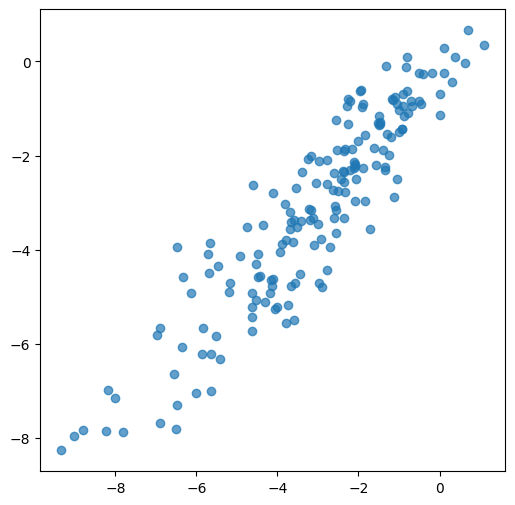

In [27]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_unscaled_predictions(model, dataloader, target_scaler):
    model.eval()

    all_preds_scaled = []
    all_targets_scaled = []

    for batch in dataloader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        pred_scaled = model(input_ids, attention_mask)

        all_preds_scaled.append(pred_scaled.cpu().numpy())
        all_targets_scaled.append(target.cpu().numpy())

    all_preds_scaled = np.concatenate(all_preds_scaled)
    all_targets_scaled = np.concatenate(all_targets_scaled)

    all_preds_unscaled = target_scaler.inverse_transform(
        all_preds_scaled.reshape(-1, 1)
    ).flatten()

    all_targets_unscaled = target_scaler.inverse_transform(
        all_targets_scaled.reshape(-1, 1)
    ).flatten()

    return all_preds_unscaled, all_targets_unscaled

test_preds, test_true = get_unscaled_predictions(
    model,
    test_loader,
    target_scaler
)

plt.figure(figsize=(6, 6))
plt.scatter(test_true, test_preds, alpha=0.7)

min_val = min(test_true.min(), test_preds.min())
max_val = max(test_true.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"Test True vs Predicted")
plt.tight_layout()
plt.show()